In [3]:
!pip install yfinance

     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 3.0/3.0 MB 22.1 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 24.6 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.18.1-py3-none-any.whl size=139097 sha256=c4693302c86fda9987da03d2eb8855d26e0784e657c313a9efe7e193406b902a
  Stored in directory: c:\users\91637\appdata\local\pip\cache\wheels\1a\57\6a\bb71346381d0d911cd4ce3026f1fa720da76707e4f01cf27dd
Successfully built peewee

   ---------------------------------------- 0/6 [peewee]
   ------

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = 15, 5

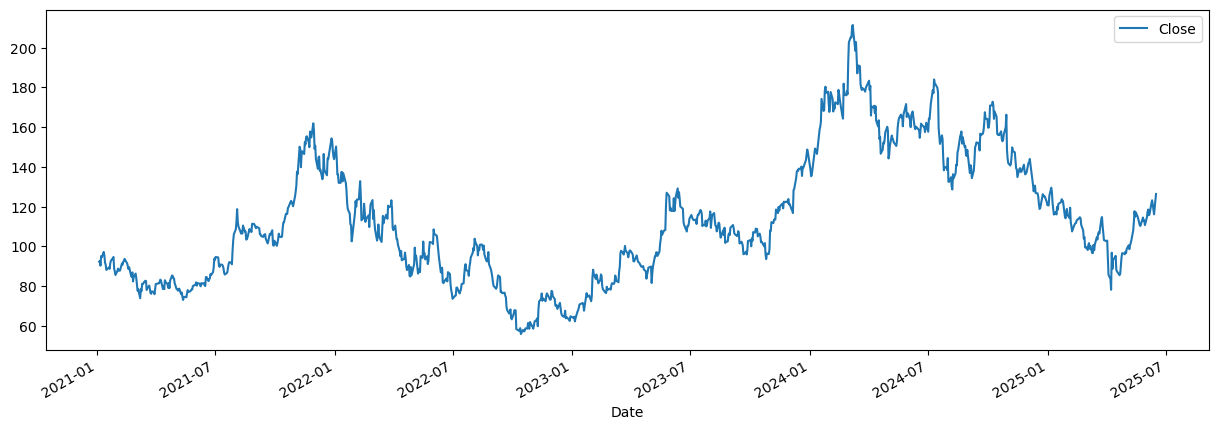

In [47]:
AMD = yf.Ticker("AMD")

# getting the historical market data
AMD_values = AMD.history(start="2021-01-01")

# Plotting the close price of AMD
AMD_values[['Close']].plot();

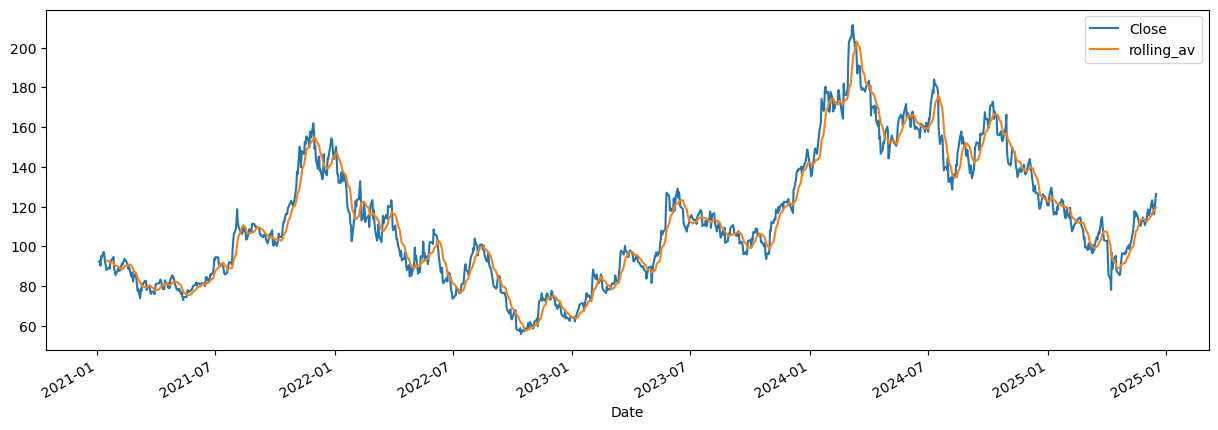

In [48]:
AMD_values['rolling_av'] = AMD_values['Close'].rolling(10).mean()

# plotting 10-day rolling average value with the closing value
AMD_values[['Close','rolling_av']].plot();

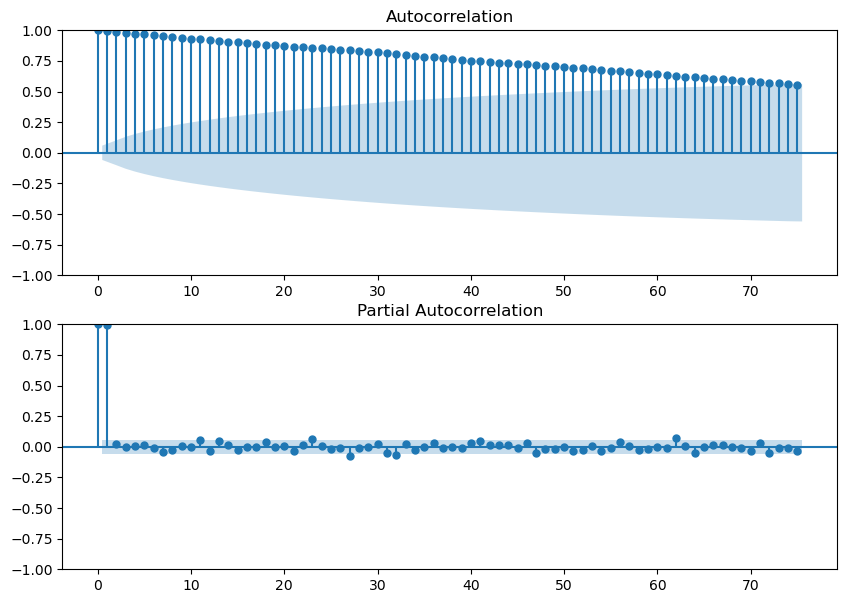

In [49]:
# Function to plot ACF and PACF
def plot_acf_pacf(timeseries):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
    plot_acf(timeseries, ax=ax1, lags=75)
    plot_pacf(timeseries, ax=ax2, lags=75)
    plt.show()


# Plotting ACF and PACF of the closing value time series
plot_acf_pacf(AMD_values['Close'])

In [21]:
# Here, we can see in the ACF plot that the first lag has a correlation of 1 
# since is the same error term as that of the current time series but from the 
# second lag we can see that the ACF plot is reducing but the 
# correlation value between the lags decreases slowly, 
# here if we model more lag values, we'll find out the order of q gets more than 50.


In [22]:
# The blue region signifies where the values are no longer statistically significant. 
# From the above plot, we can that see that the last significant lag is the 55. Therefore,
# our model order for the MA model will be 55. The value of q to be 55 which means the current 
# value will depend on the last 55 error values of the data.

In [23]:
# In the next step we will be fitting an ARIMA model to the closing prices of AMD stock with an order of (0, 0, 55),
# indicating 55 lags for the moving average component or the order of the moving average model to be 55. 
# After that we will be printing the summary of the fitted ARIMA model such that the coefficient of the past noise values could be analyzed.

In [95]:
#creating the model
MA_model = ARIMA(endog=AMD_values['Close'], order=(0, 0, 69))

#fitting data to the model
results = MA_model.fit()

#summary of the model
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1118
Model:                ARIMA(0, 0, 69)   Log Likelihood               -3020.315
Date:                Tue, 17 Jun 2025   AIC                           6182.630
Time:                        17:03:42   BIC                           6539.000
Sample:                             0   HQIC                          6317.340
                               - 1118                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        112.6908      7.158     15.743      0.000      98.661     126.721
ma.L1          0.9862      0.030     32.352      0.000       0.926       1.046
ma.L2          1.0003      0.043     23.019      0.0

In [73]:
# print(results.summary())

In [71]:
# #prediction data
# AMD_values.index = AMD_values.index.tz_localize(None)


# start_date = pd.to_datetime('2023-12-15')
# end_date = pd.to_datetime('2024-02-05')

# AMD_values['prediction'] = results.predict(start=start_date, end=end_date)

# #printing last 14 values of the prediction with original and rolling avg value
# print(AMD_values[['Close','rolling_av','prediction']].tail(14))

In [88]:
start_date = '2025-1-15'
end_date   = '2025-6-16'
AMD_values['prediction'] = results.predict(start=start_date, end=end_date)


In [89]:
print(AMD_values[['Close','rolling_av','prediction']].tail(14))

                 Close  rolling_av  prediction
Date                                          
2025-05-28  112.860001  113.862999  114.594354
2025-05-29  113.029999  113.393999  110.662144
2025-05-30  110.730003  112.967999  111.543778
2025-06-02  114.629997  112.713999  108.526207
2025-06-03  117.309998  112.970999  114.012361
2025-06-04  118.580002  113.477999  118.202100
2025-06-05  115.690002  113.841000  118.910154
2025-06-06  116.190002  114.389000  114.964347
2025-06-09  121.730003  115.531001  115.798983
2025-06-10  123.239998  116.399001  122.437965
2025-06-11  121.139999  117.227000  122.682486
2025-06-12  118.500000  117.774001  120.321218
2025-06-13  116.160004  118.317001  116.093069
2025-06-16  126.389999  119.493001  115.428134


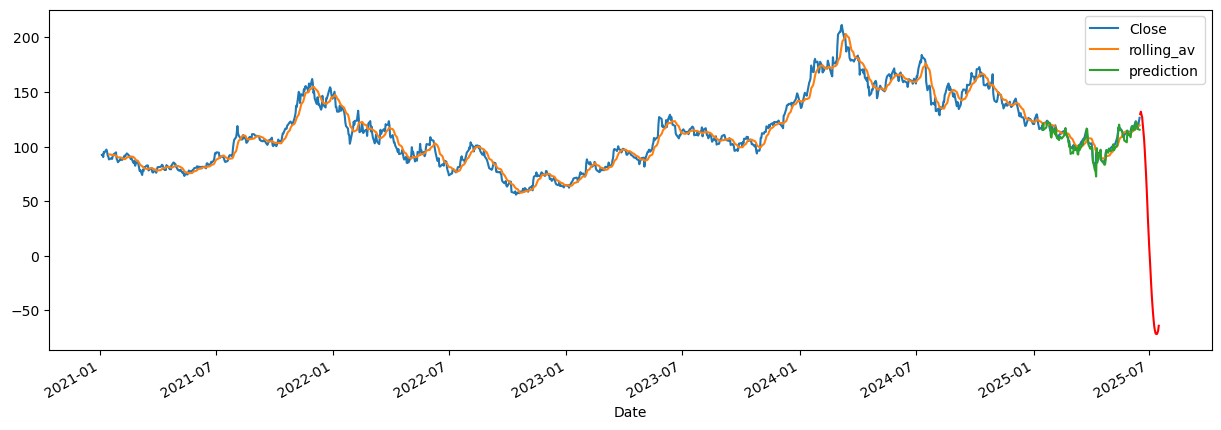

In [90]:
# Forecast future values
# Forecast future closing prices
forecast_steps = 30  # Forecasting for the next 30 days
forecast_index = pd.date_range(start=AMD_values['Close'].index[-1], periods=forecast_steps+1, freq='D')[1:]  # Generate datetime index for forecast
forecast = results.forecast(steps=forecast_steps)

# plotting the end results
AMD_values[['Close','rolling_av','prediction']].plot()
plt.plot(forecast_index, forecast, color='red', label='Forecast')

In [94]:
# # Forecast next 30 days
# future_forecast = results.forecast(steps=30)

# # If needed, create future dates
# last_date = AMD_values.index[-1]  # Get the last date in your data
# future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

# # Combine dates and predictions
# forecast_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_forecast})
# forecast_df.set_index('Date', inplace=True)

# # Optional: plot it
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,5))
# plt.plot(AMD_values['Close'], label='Historical')
# plt.plot(forecast_df['Forecast'], label='Forecast', color='red')
# plt.legend()
# plt.title('Forecast for Next 30 Days')
# plt.show()


In [93]:
# # Forecast next 30 days
# future_forecast = results.forecast(steps=30)

# # Get last date from your dataset
# last_date = AMD_values.index[-1]

# # Create future dates
# future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

# # Create a DataFrame
# forecast_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_forecast})
# forecast_df.set_index('Date', inplace=True)

# # Print forecast values
# print(forecast_df)


In [96]:
# Exp Smoothening

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

In [104]:
df=pd.read_csv('AirPassengers.csv',parse_dates=['Month'],index_col='Month')

In [ ]:
# The parse_dates parameter in pandas functions like read_csv() is used to 
# automatically convert date columns from string format into datetime objects when reading a file.



In [105]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


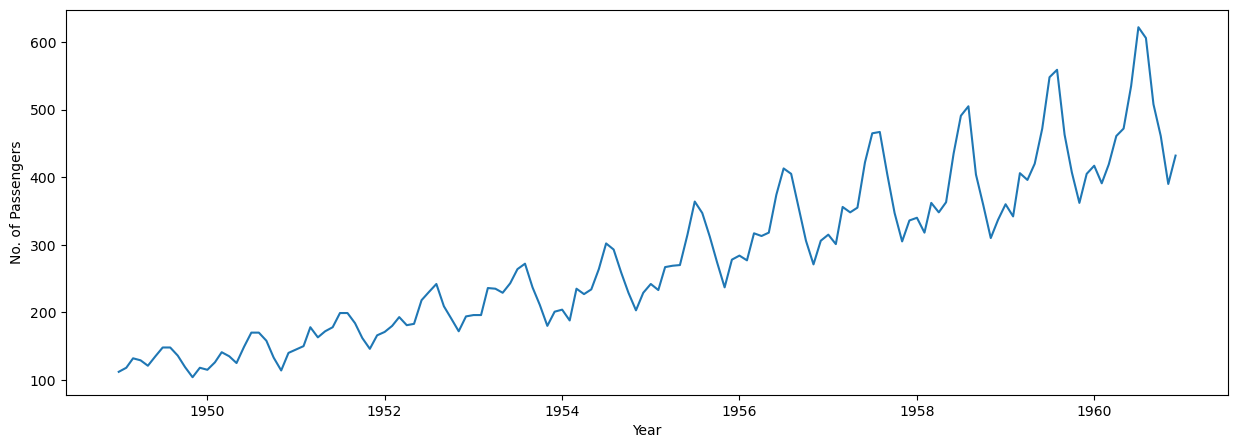

In [107]:
plt.plot(df)
plt.xlabel('Year')
plt.ylabel('No. of Passengers')
plt.show()

In [108]:
# We can see that the number of passengers appears to be increasing over time, with some seasonality as well.

In [109]:
# Single Exponential Smoothening

In [113]:
from statsmodels.tsa.api import SimpleExpSmoothing

model=SimpleExpSmoothing(df)
model_single_fit=model.fit()

In [114]:
forecast_single = model_single_fit.forecast(6)  ## Next 6 months
print(forecast_single)

1961-01-01    431.791781
1961-02-01    431.791781
1961-03-01    431.791781
1961-04-01    431.791781
1961-05-01    431.791781
1961-06-01    431.791781
Freq: MS, dtype: float64


In [115]:
forecast_single = model_single_fit.forecast(40)  ## Next 40 months
print(forecast_single)

1961-01-01    431.791781
1961-02-01    431.791781
1961-03-01    431.791781
1961-04-01    431.791781
1961-05-01    431.791781
1961-06-01    431.791781
1961-07-01    431.791781
1961-08-01    431.791781
1961-09-01    431.791781
1961-10-01    431.791781
1961-11-01    431.791781
1961-12-01    431.791781
1962-01-01    431.791781
1962-02-01    431.791781
1962-03-01    431.791781
1962-04-01    431.791781
1962-05-01    431.791781
1962-06-01    431.791781
1962-07-01    431.791781
1962-08-01    431.791781
1962-09-01    431.791781
1962-10-01    431.791781
1962-11-01    431.791781
1962-12-01    431.791781
1963-01-01    431.791781
1963-02-01    431.791781
1963-03-01    431.791781
1963-04-01    431.791781
1963-05-01    431.791781
1963-06-01    431.791781
1963-07-01    431.791781
1963-08-01    431.791781
1963-09-01    431.791781
1963-10-01    431.791781
1963-11-01    431.791781
1963-12-01    431.791781
1964-01-01    431.791781
1964-02-01    431.791781
1964-03-01    431.791781
1964-04-01    431.791781


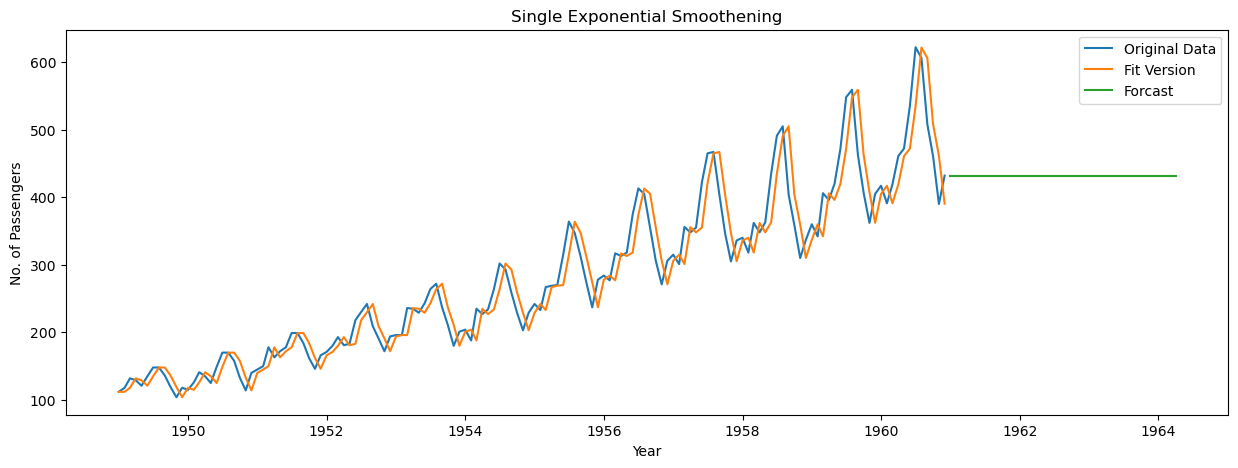

In [117]:
plt.plot(df, label='Original Data')
plt.plot(model_single_fit.fittedvalues, label='Fit Version')
plt.plot(forecast_single, label='Forcast')

plt.xlabel('Year')
plt.ylabel('No. of Passengers')
plt.title('Single Exponential Smoothening')

plt.legend()
plt.show()

In [118]:
# Double Exp. Smooth.


In [119]:
from statsmodels.tsa.api import Holt

model_dbl= Holt(df)
model_dbl_fit= model_dbl.fit()

In [120]:
forecast_dbl= model_dbl_fit.forecast(6)
print(forecast_dbl)

1961-01-01    436.196220
1961-02-01    440.578651
1961-03-01    444.961083
1961-04-01    449.343515
1961-05-01    453.725946
1961-06-01    458.108378
Freq: MS, dtype: float64


In [121]:
forecast_dbl= model_dbl_fit.forecast(40)
print(forecast_dbl)

1961-01-01    436.196220
1961-02-01    440.578651
1961-03-01    444.961083
1961-04-01    449.343515
1961-05-01    453.725946
1961-06-01    458.108378
1961-07-01    462.490810
1961-08-01    466.873241
1961-09-01    471.255673
1961-10-01    475.638104
1961-11-01    480.020536
1961-12-01    484.402968
1962-01-01    488.785399
1962-02-01    493.167831
1962-03-01    497.550262
1962-04-01    501.932694
1962-05-01    506.315126
1962-06-01    510.697557
1962-07-01    515.079989
1962-08-01    519.462421
1962-09-01    523.844852
1962-10-01    528.227284
1962-11-01    532.609715
1962-12-01    536.992147
1963-01-01    541.374579
1963-02-01    545.757010
1963-03-01    550.139442
1963-04-01    554.521873
1963-05-01    558.904305
1963-06-01    563.286737
1963-07-01    567.669168
1963-08-01    572.051600
1963-09-01    576.434032
1963-10-01    580.816463
1963-11-01    585.198895
1963-12-01    589.581326
1964-01-01    593.963758
1964-02-01    598.346190
1964-03-01    602.728621
1964-04-01    607.111053


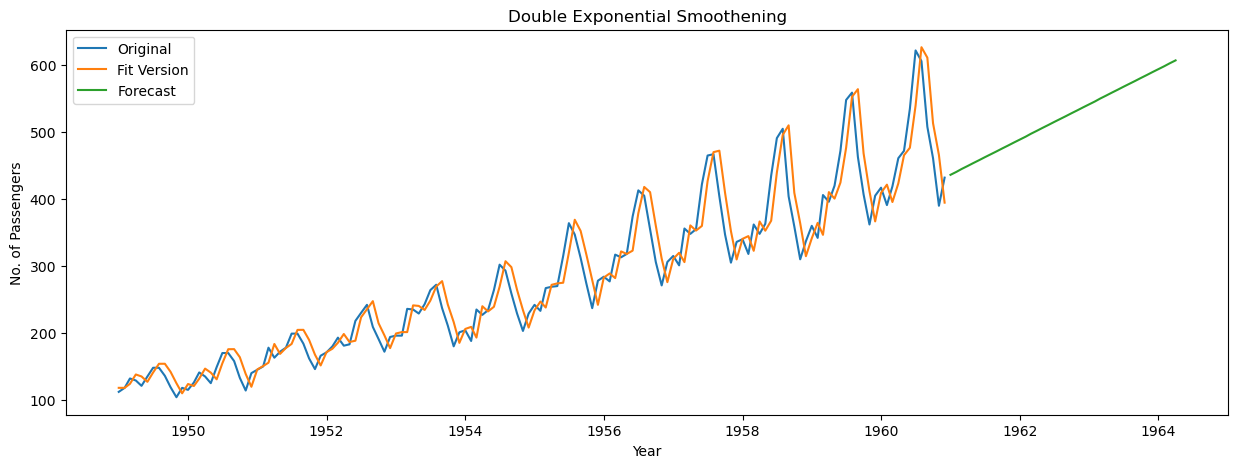

In [123]:
plt.plot(df, label='Original')
plt.plot(model_dbl_fit.fittedvalues, label='Fit Version')
plt.plot(forecast_dbl, label='Forecast')

plt.xlabel('Year')
plt.ylabel('No. of Passengers')
plt.title('Double Exponential Smoothening')

plt.legend()
plt.show()

In [124]:
# Holt-Winter seasonal smoothening

In [129]:
from statsmodels.tsa.api import ExponentialSmoothing

model_trpl= ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='add')
mdl_trpl_fit= model_trpl.fit()

In [130]:
frcst_trpl= mdl_trpl_fit.forecast(6)
print(frcst_trpl)

1961-01-01    451.577073
1961-02-01    427.257748
1961-03-01    464.699360
1961-04-01    500.103185
1961-05-01    508.660794
1961-06-01    567.713873
Freq: MS, dtype: float64


In [132]:
frcst_trpl= mdl_trpl_fit.forecast(40)
print(frcst_trpl)

1961-01-01    451.577073
1961-02-01    427.257748
1961-03-01    464.699360
1961-04-01    500.103185
1961-05-01    508.660794
1961-06-01    567.713873
1961-07-01    647.897121
1961-08-01    632.460961
1961-09-01    534.374265
1961-10-01    484.930880
1961-11-01    418.459518
1961-12-01    471.058935
1962-01-01    482.713397
1962-02-01    458.394072
1962-03-01    495.835684
1962-04-01    531.239509
1962-05-01    539.797117
1962-06-01    598.850197
1962-07-01    679.033444
1962-08-01    663.597285
1962-09-01    565.510589
1962-10-01    516.067203
1962-11-01    449.595842
1962-12-01    502.195259
1963-01-01    513.849721
1963-02-01    489.530396
1963-03-01    526.972008
1963-04-01    562.375833
1963-05-01    570.933441
1963-06-01    629.986520
1963-07-01    710.169768
1963-08-01    694.733609
1963-09-01    596.646913
1963-10-01    547.203527
1963-11-01    480.732166
1963-12-01    533.331583
1964-01-01    544.986045
1964-02-01    520.666720
1964-03-01    558.108332
1964-04-01    593.512157


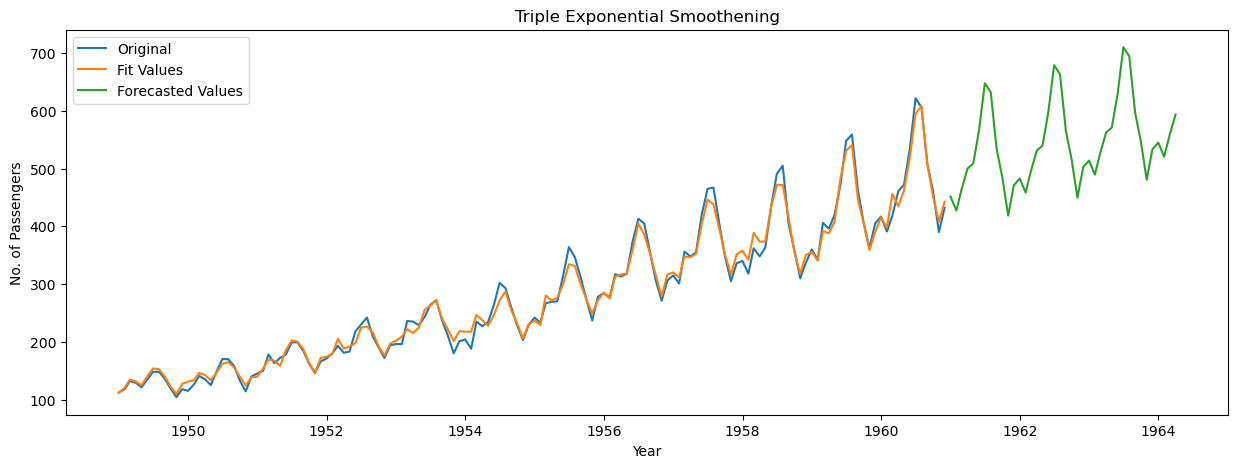

In [133]:
plt.plot(df, label='Original')
plt.plot(mdl_trpl_fit.fittedvalues, label='Fit Values')
plt.plot(frcst_trpl, label='Forecasted Values')

plt.xlabel('Year')
plt.ylabel('No. of Passengers')
plt.title('Triple Exponential Smoothening')

plt.legend()
plt.show()